# Week 5 Tutorial - Classical ML Deep Dive

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with different data

At the end: one capstone that runs all algorithms side-by-side.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

%matplotlib inline
np.random.seed(42)
print('Setup complete.')

Setup complete.


---
## §1 - k-Nearest Neighbors (kNN)

Read `study-guide.md §1` first, then work through this section.

In [40]:
# EXAMPLE: kNN on breast cancer dataset
# See how k affects the decision boundary and performance

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different values of k
print(f'{"k":>4}  {"CV F1 (train)"}')
print('-' * 22)

for k in [1, 3, 5, 10, 20, 50]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1').mean()
    print(f'{k:>4}  {cv_f1:>13.4f}')

print()
print('k=1: overfits (memorizes training data)')
print('Large k: underfits (ignores local structure)')
print('Sweet spot is somewhere in the middle')
print()
print('CV is run on training data only. Test set is touched once at the very end.')


   k  CV F1 (train)
----------------------
   1         0.9546
   3         0.9759
   5         0.9740
  10         0.9722
  20         0.9691
  50         0.9577

k=1: overfits (memorizes training data)
Large k: underfits (ignores local structure)
Sweet spot is somewhere in the middle

CV is run on training data only. Test set is touched once at the very end.


In [41]:
# EXAMPLE: visualize why scaling matters for kNN
# Compare kNN with and without StandardScaler

from sklearn.metrics import f1_score

for label, pipe in [
    ('Unscaled kNN', Pipeline([('knn', KNeighborsClassifier(n_neighbors=5))])),
    ('Scaled kNN',   Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])),
]:
    pipe.fit(X_train, y_train)
    f1 = f1_score(y_test, pipe.predict(X_test))
    print(f'{label}: F1 = {f1:.4f}')

print()
print('Scaled kNN performs better because all features contribute equally to distance.')
print('Without scaling, features with large values (e.g. worst area ~2500) dominate')
print('over features with small values (e.g. smoothness ~0.1).')

Unscaled kNN: F1 = 0.9296
Scaled kNN: F1 = 0.9655

Scaled kNN performs better because all features contribute equally to distance.
Without scaling, features with large values (e.g. worst area ~2500) dominate
over features with small values (e.g. smoothness ~0.1).


In [42]:
# DO IT YOURSELF §1
# Dataset: wine dataset (3 classes, 13 features)
wine = load_wine()
X_w, y_w = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_w, y_w, test_size=0.2, random_state=42, stratify=y_w)
#
# 1. Try k = 1, 3, 5, 10, 15 using a Pipeline with StandardScaler
# 2. For each k, print the test accuracy (use scoring='accuracy')
# 3. Which k performs best?
# 4. Train the best k and print its classification report

# YOUR CODE HERE
for k in [1, 3, 5, 10]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_f1 = cross_val_score(pipe, X_w_train, y_w_train, cv=5, scoring='accuracy').mean()
    print(f'{k:>4}  {cv_f1:>13.4f}')


# k = 10 performed the best
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=10))
])

pipe2.fit(X_w_train, y_w_train)
y_w_pred = pipe2.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))
print(y_w_pred)
print(y_w_test)
print(len(wine.data))

   1         0.9367
   3         0.9512
   5         0.9650
  10         0.9722
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
[0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
178


---
## §2 - Logistic Regression (deeper dive)

Read `study-guide.md §2` first, then work through this section.

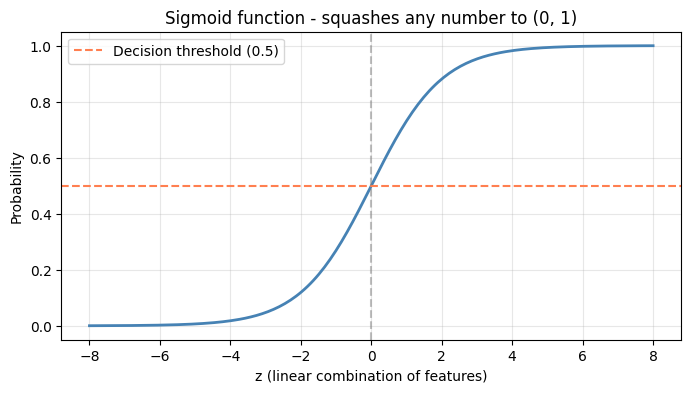

z < 0  ->  probability < 0.5  ->  predict class 0
z > 0  ->  probability > 0.5  ->  predict class 1
z = 0  ->  probability = 0.5  ->  decision boundary


In [43]:
# EXAMPLE: visualize the sigmoid function

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), 'steelblue', lw=2)
plt.axhline(0.5, color='coral', linestyle='--', label='Decision threshold (0.5)')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z (linear combination of features)')
plt.ylabel('Probability')
plt.title('Sigmoid function - squashes any number to (0, 1)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('z < 0  ->  probability < 0.5  ->  predict class 0')
print('z > 0  ->  probability > 0.5  ->  predict class 1')
print('z = 0  ->  probability = 0.5  ->  decision boundary')

In [44]:
# EXAMPLE: train logistic regression and inspect feature weights

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, random_state=42))
])
pipe_lr.fit(X_train, y_train)

# Feature weights - which features matter most?
weights = pipe_lr.named_steps['lr'].coef_[0]
feature_names = cancer.feature_names

# Sort by absolute weight
sorted_idx = np.argsort(np.abs(weights))[::-1]

print('Top 10 most important features (by weight magnitude):')
print(f'{"Feature":<35} {"Weight":>8}')
print('-' * 45)
for i in sorted_idx[:10]:
    print(f'{feature_names[i]:<35} {weights[i]:>8.4f}')

print()
print('Positive weight -> feature pushes toward class 1 (benign)')
print('Negative weight -> feature pushes toward class 0 (malignant)')

Top 10 most important features (by weight magnitude):
Feature                               Weight
---------------------------------------------
worst texture                        -1.2551
radius error                         -1.0830
worst concave points                 -0.9537
worst area                           -0.9478
worst radius                         -0.9476
worst symmetry                       -0.9392
area error                           -0.9291
worst concavity                      -0.8232
worst perimeter                      -0.7632
worst smoothness                     -0.7466

Positive weight -> feature pushes toward class 1 (benign)
Negative weight -> feature pushes toward class 0 (malignant)


In [56]:
# DO IT YOURSELF §2
# Dataset: wine (same as §1)
#
# 1. Train a LogisticRegression (max_iter=5000) on the wine dataset using a Pipeline
# 2. Print test accuracy and classification report
# 3. Print the top 5 most important features for class 0 (most negative weights)
#    and top 5 for class 2 (most positive weights in coef_[2])
# Hint: LogisticRegression on multi-class has coef_ shape (n_classes, n_features)

# YOUR CODE HERE
pipe_lr = Pipeline([
    ('scaaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, random_state=42))
])

pipe_lr.fit(X_w_train, y_w_train)

weights = pipe_lr.named_steps['lr'].coef_[2]
feature_names = wine.feature_names

# Sort by absolute weight
reverse_sorted_idx = np.argsort(weights)[::-1]

print('Top 5 most important features for class 0:')
print(f'{"Feature":<35} {"Weight":>8}')
print('-' * 45)
for i in reverse_sorted_idx[:5]:
    print(f'{feature_names[i]:<35} {weights[i]:>8.4f}')

sorted_idx = np.argsort(weights)
print('Top 5 most important features class 1:')
print(f'{"Feature":<35} {"Weight":>8}')
print('-' * 45)
for i in sorted_idx[:5]:
    print(f'{feature_names[i]:<35} {weights[i]:>8.4f}')





Top 5 most important features for class 0:
Feature                               Weight
---------------------------------------------
color_intensity                       0.8758
alcalinity_of_ash                     0.3688
ash                                   0.3471
malic_acid                            0.3446
alcohol                               0.1441
Top 5 most important features class 1:
Feature                               Weight
---------------------------------------------
flavanoids                           -0.9035
hue                                  -0.7056
od280/od315_of_diluted_wines         -0.5689
proanthocyanins                      -0.4958
total_phenols                        -0.2886


---
## §3 - Support Vector Machines (SVM)

Read `study-guide.md §3` first, then work through this section.

In [57]:
# EXAMPLE: SVM with different kernels on breast cancer

kernels = ['linear', 'rbf', 'poly']

print(f'{"Kernel":<10}  {"CV F1 (mean)":>12}  {"CV F1 (std)":>11}')
print('-' * 38)

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel, random_state=42))
    ])
    scores = cross_val_score(pipe_svm, X, y, cv=5, scoring='f1')
    print(f'{kernel:<10}  {scores.mean():>12.4f}  {scores.std():>11.4f}')

print()
print('rbf usually wins on real datasets - it handles non-linear boundaries')

Kernel      CV F1 (mean)  CV F1 (std)
--------------------------------------
linear            0.9779       0.0066
rbf               0.9791       0.0115
poly              0.9287       0.0158

rbf usually wins on real datasets - it handles non-linear boundaries


In [58]:
# EXAMPLE: effect of C parameter (regularization)
# C controls the trade-off between margin size and misclassification
# Small C = larger margin, more misclassifications allowed (simpler model)
# Large C = smaller margin, fewer misclassifications (more complex model)

print(f'{"C":>8}  {"CV F1":>8}')
print('-' * 20)
for C in [0.01, 0.1, 1, 10, 100]:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=C, random_state=42))
    ])
    score = cross_val_score(pipe_svm, X, y, cv=5, scoring='f1').mean()
    print(f'{C:>8}  {score:>8.4f}')

       C     CV F1
--------------------
    0.01    0.7711
     0.1    0.9573
       1    0.9791
      10    0.9819
     100    0.9661


In [73]:
# DO IT YOURSELF §3
# Dataset: wine
#
# 1. Train SVM with rbf kernel on the wine dataset
# 2. Try C = 0.1, 1, 10, 100 - print CV accuracy for each
# 3. Train the best C and print its classification report
# 4. Comment: how does SVM compare to kNN from §1 on this dataset?

# YOUR CODE HERE
for C in [0.1, 1, 10, 100]:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', random_state=42, C=C))
    ])

    score = cross_val_score(pipe_svm, X_w, y_w, cv=5, scoring='accuracy').mean()
    print(f'{C:>8}  {score:>8.4f}')

best_C = 10
pipe_svm_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42, C=best_C))
])
pipe_svm_best.fit(X_w_train, y_w_train)
y_w_pred = pipe_svm_best.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))
print(y_w_pred)
print(y_w_test)

## In terms of result its less accurate than knn, this suggests that some datas are almost too close to each other where
## clear separation is difficult


     0.1    0.9663
       1    0.9833
      10    0.9889
     100    0.9889
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

[0 1 0 1 1 0 0 1 1 2 1 2 0 1 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
[0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


---
## §4 - Naive Bayes

Read `study-guide.md §4` first, then work through this section.

In [74]:
# EXAMPLE: Naive Bayes on breast cancer
# GaussianNB assumes features follow a normal distribution within each class

# Note: Naive Bayes doesn't need scaling (it models distributions, not distances)
nb = GaussianNB()
nb.fit(X_train, y_train)

scores = cross_val_score(nb, X, y, cv=5, scoring='f1')
print(f'Naive Bayes CV F1: {scores.mean():.4f} Â± {scores.std():.4f}')
print()
print(classification_report(y_test, nb.predict(X_test), target_names=cancer.target_names))
print()
print('Despite the naive independence assumption, NB still performs reasonably.')
print('And it trained almost instantly - no gradient descent needed.')

Naive Bayes CV F1: 0.9518 Â± 0.0116

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


Despite the naive independence assumption, NB still performs reasonably.
And it trained almost instantly - no gradient descent needed.


In [77]:
# DO IT YOURSELF §4
# Dataset: wine
#
# 1. Train GaussianNB on the wine dataset (no scaling needed)
# 2. Print CV accuracy and classification report
# 3. Compare to your kNN and SVM results from §1 and §3
#    Which algorithm performed best on wine so far?

# YOUR CODE HERE
nb = GaussianNB()
nb.fit(X_w_train, y_w_train)
scores = cross_val_score(nb, X_w, y_w, cv=5, scoring='accuracy')
print(f'Naive Bayes CV F1: {scores.mean():.4f} Â± {scores.std():.4f}')
print()
print(classification_report(y_w_test, nb.predict(X_w_test), target_names=wine.target_names))

##based on result, I would go for KNN as it shows highes accuracy


Naive Bayes CV F1: 0.9663 Â± 0.0211

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



---
## §5 - Comparing Algorithms

Read `study-guide.md §5` first, then work through this section.

In [78]:
# EXAMPLE: run all algorithms on breast cancer and compare

models = {
    'kNN (k=5)':           Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=5000))]),
    'SVM (rbf)':           Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf'))]),
    'Naive Bayes':         Pipeline([('model', GaussianNB())]),
}

print(f'{"Model":<25}  {"CV F1 mean":>10}  {"CV F1 std":>10}')
print('-' * 50)

results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    results[name] = scores
    print(f'{name:<25}  {scores.mean():>10.4f}  {scores.std():>10.4f}')

Model                      CV F1 mean   CV F1 std
--------------------------------------------------
kNN (k=5)                      0.9723      0.0074
Logistic Regression            0.9848      0.0050
SVM (rbf)                      0.9791      0.0115
Naive Bayes                    0.9518      0.0116


C:\Users\yoonh\AppData\Local\Temp\ipykernel_28760\617908743.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)


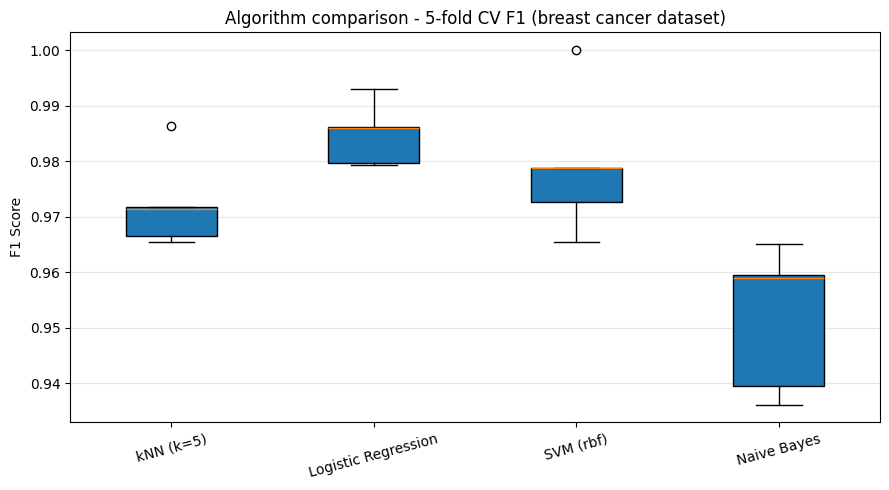

Box shows the spread across folds.
A model with high mean AND small spread is consistently good.


In [79]:
# EXAMPLE: visualize the comparison as a box plot

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)
ax.set_ylabel('F1 Score')
ax.set_title('Algorithm comparison - 5-fold CV F1 (breast cancer dataset)')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('Box shows the spread across folds.')
print('A model with high mean AND small spread is consistently good.')

Model                      CV F1 mean   CV F1 std
--------------------------------------------------
kNN (k=5)                      0.9494      0.0379
Logistic Regression            0.9832      0.0137
SVM (rbf)                      0.9833      0.0222
Naive Bayes                    0.9663      0.0211


C:\Users\yoonh\AppData\Local\Temp\ipykernel_28760\2996984409.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)


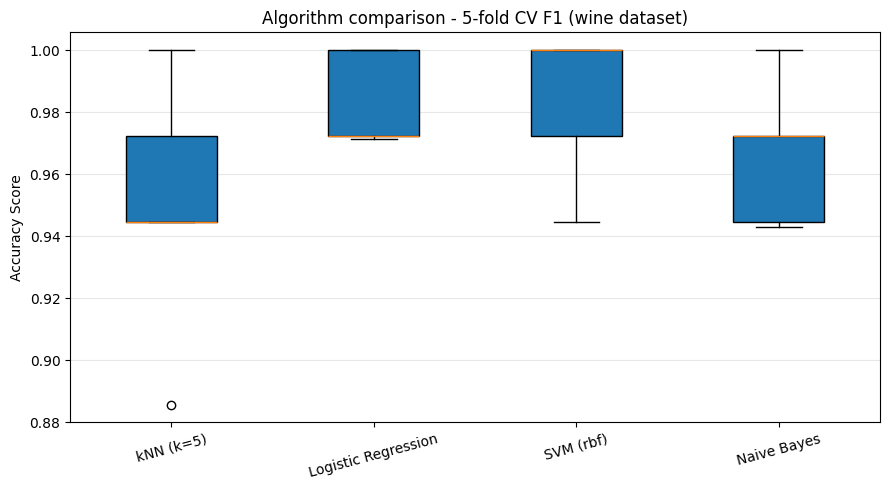

Box shows the spread across folds.
A model with high mean AND small spread is consistently good.


In [ ]:
# DO IT YOURSELF §5
# Dataset: wine
#
# 1. Run all 4 algorithms on the wine dataset using cross_val_score (scoring='accuracy')
# 2. Print mean Â± std for each
# 3. Plot a box plot comparing all 4
# 4. Which algorithm would you choose for this dataset and why?
#    Write your reasoning as a comment.

# YOUR CODE HERE
models = {
    'kNN (k=5)':           Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=5000))]),
    'SVM (rbf)':           Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf'))]),
    'Naive Bayes':         Pipeline([('model', GaussianNB())]),
}

print(f'{"Model":<25}  {"CV F1 mean":>10}  {"CV F1 std":>10}')
print('-' * 50)

results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_w, y_w, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25}  {scores.mean():>10.4f}  {scores.std():>10.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)
ax.set_ylabel('Accuracy Score')
ax.set_title('Algorithm comparison - 5-fold CV F1 (wine dataset)')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('Box shows the spread across folds.')
print('A model with high mean AND small spread is consistently good.')

# Based on algorithm comparison Logistic Regression has performed best in terms of score and small std
# But from previous example, it was shown that wine performed better. It could be that because test data was split, result may have be overfit
# due to smaller dataset
# or it could be that we are using more neighbours in the previous example which could be we are overfitting

---
## §6 - PCA

Read `study-guide.md §6` first, then work through this section.

In [85]:
# EXAMPLE: reduce breast cancer (30 features) to 2D and visualize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print(f'Original shape: {X.shape}')
print(f'After PCA:      {X_2d.shape}')
print()
print(f'Component 1 explains: {pca.explained_variance_ratio_[0]:.1%} of variance')
print(f'Component 2 explains: {pca.explained_variance_ratio_[1]:.1%} of variance')
print(f'Total explained:      {sum(pca.explained_variance_ratio_):.1%} of variance')

Original shape: (569, 30)
After PCA:      (569, 2)

Component 1 explains: 44.3% of variance
Component 2 explains: 19.0% of variance
Total explained:      63.2% of variance


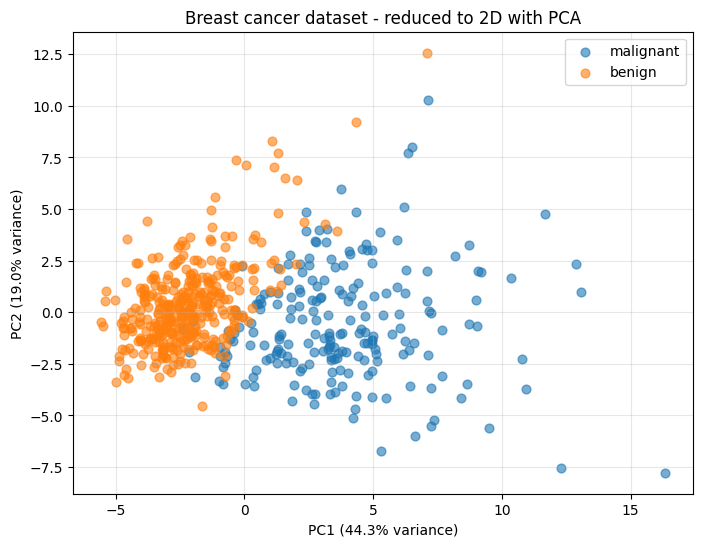

The two classes are largely separable even in 2D.
PCA found the directions that spread the data out most - and the classes happen to separate there.


In [86]:
# EXAMPLE: visualize the 2D projection - can you see the two classes separate?

fig, ax = plt.subplots(figsize=(8, 6))
for class_idx, class_name in enumerate(cancer.target_names):
    mask = y == class_idx
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_name, alpha=0.6, s=40)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Breast cancer dataset - reduced to 2D with PCA')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print('The two classes are largely separable even in 2D.')
print('PCA found the directions that spread the data out most - and the classes happen to separate there.')

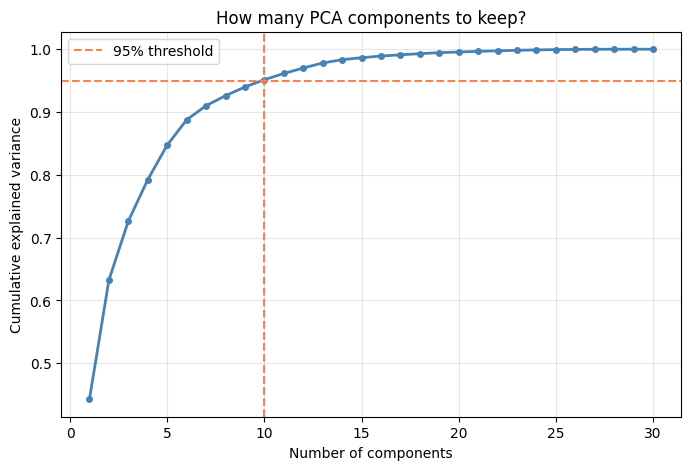

10 components explain 95% of variance (out of 30 original features)
That is a 67% reduction in dimensionality


In [87]:
# EXAMPLE: how many components do you need to explain 95% of variance?

pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, 'steelblue', lw=2, marker='o', markersize=4)
plt.axhline(0.95, color='coral', linestyle='--', label='95% threshold')
plt.axvline(n_95, color='coral', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('How many PCA components to keep?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'{n_95} components explain 95% of variance (out of 30 original features)')
print(f'That is a {(1 - n_95/30):.0%} reduction in dimensionality')

Original shape: (178, 13)
After PCA:      (178, 2)

Component 1 explains: 36.2% of variance
Component 2 explains: 19.2% of variance


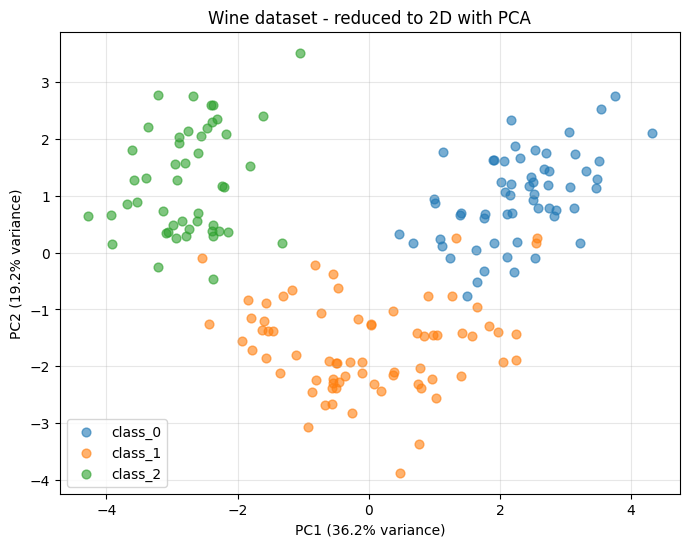

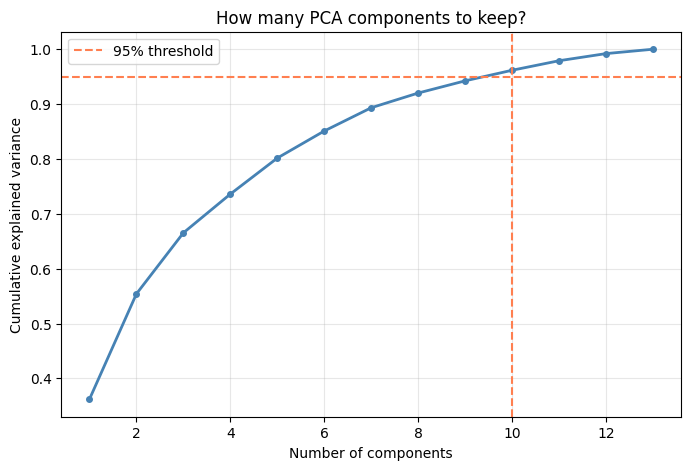

In [ ]:
# DO IT YOURSELF §6
# Dataset: wine (13 features, 3 classes)
#
# 1. Scale the wine data and apply PCA to reduce to 2 components
# 2. Print how much variance each component explains
# 3. Plot the 2D projection colored by wine class (3 colors)
# 4. Plot the cumulative explained variance curve
# 5. How many components are needed to explain 95% of variance?

# YOUR CODE HERE
scaler = StandardScaler()
X_w_scaled = scaler.fit_transform(X_w)
pca = PCA(n_components=2)
X_w_2d = pca.fit_transform(X_w_scaled)
print(f'Original shape: {X_w.shape}')
print(f'After PCA:      {X_w_2d.shape}')
print()
print(f'Component 1 explains: {pca.explained_variance_ratio_[0]:.1%} of variance')
print(f'Component 2 explains: {pca.explained_variance_ratio_[1]:.1%} of variance')

fig, ax = plt.subplots(figsize=(8, 6))
for class_idx, class_name in enumerate(wine.target_names):
    mask = y_w == class_idx
    ax.scatter(X_w_2d[mask, 0], X_w_2d[mask, 1], label=class_name, alpha=0.6, s=40)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Wine dataset - reduced to 2D with PCA')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

pca_full = PCA()
pca_full.fit(X_w_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, 'steelblue', lw=2, marker='o', markersize=4)
plt.axhline(0.95, color='coral', linestyle='--', label='95% threshold')
plt.axvline(n_95, color='coral', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('How many PCA components to keep?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#10

---
## Capstone - All Algorithms Side by Side

Pick the best algorithm from this week and build a full evaluation pipeline.

In [102]:
# Dataset: wine
print('Wine dataset:')
print(f'  Samples:  {X_w.shape[0]}')
print(f'  Features: {X_w.shape[1]}')
print(f'  Classes:  {wine.target_names}')
print(f'  Distribution: {np.bincount(y_w)}')

Wine dataset:
  Samples:  178
  Features: 13
  Classes:  ['class_0' 'class_1' 'class_2']
  Distribution: [59 71 48]


Model                      CV Accuracy mean  CV Accuracy std
--------------------------------------------------
kNN (k=5)                      0.9494      0.0379
Logistic Regression            0.9832      0.0137
SVM (rbf)                      0.9833      0.0222
Naive Bayes                    0.9663      0.0211


C:\Users\yoonh\AppData\Local\Temp\ipykernel_28760\3294310840.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)


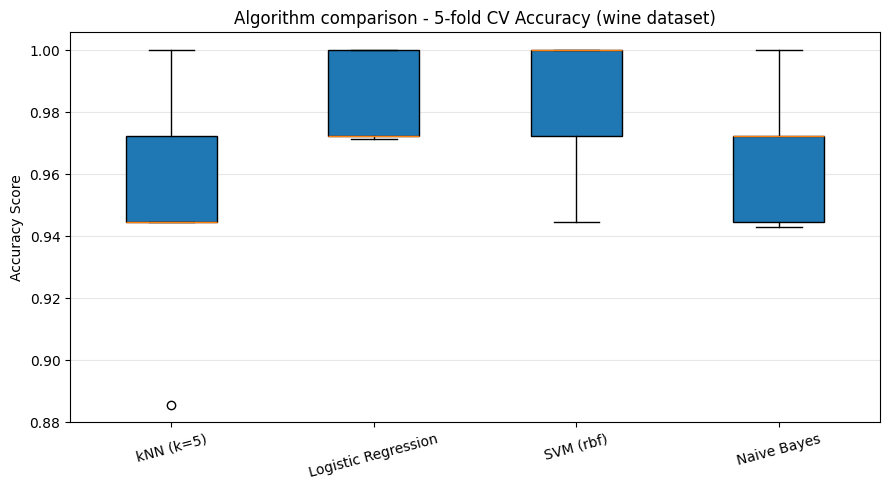

Best one before PCA is Logistic Regression
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

PCA with KNN
              precision    recall  f1-score   support

     class_0       0.92      0.92      0.92        12
     class_1       0.87      0.93      0.90        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



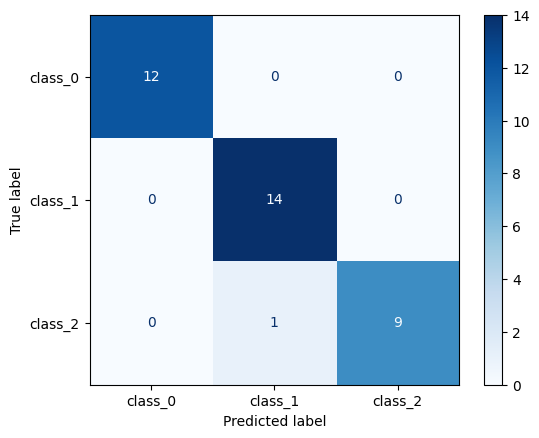

In [107]:
# CAPSTONE:
# 1. Run all 4 algorithms (kNN, LogReg, SVM, NaiveBayes) on the wine dataset
# 2. Use 5-fold cross-validation, scoring='accuracy'
# 3. Print mean Â± std for each
# 4. Pick the best algorithm
# 5. Train it on the full training set, evaluate on test set
# 6. Print classification report
# 7. Plot confusion matrix
# 8. Apply PCA (2 components) and re-run the best algorithm - does it perform better or worse?
# 9. Written answer: why do you think PCA helped or hurt here?

# YOUR CODE HERE
models = {
    'kNN (k=5)':           Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=5000))]),
    'SVM (rbf)':           Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf'))]),
    'Naive Bayes':         Pipeline([('model', GaussianNB())]),
}

print(f'{"Model":<25}  {"CV Accuracy mean":>10}  {"CV Accuracy std":>10}')
print('-' * 50)

results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_w, y_w, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25}  {scores.mean():>10.4f}  {scores.std():>10.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)
ax.set_ylabel('Accuracy Score')
ax.set_title('Algorithm comparison - 5-fold CV Accuracy (wine dataset)')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Best one before PCA is Logistic Regression")


pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000))
])

pipe2.fit(X_w_train, y_w_train)
y_w_pred = pipe2.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

cm = confusion_matrix(y_w_test, y_w_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap=plt.cm.Blues)

best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('lr', LogisticRegression(max_iter=5000))
])

print("PCA with KNN")
best_pipe.fit(X_w_train, y_w_train)
y_w_pred_2 = best_pipe.predict(X_w_test)
print(classification_report(y_w_test, y_w_pred_2, target_names=wine.target_names))

# Appears that pca hurt in this case might be that in this case low variance is not noise but pattern
